# MindBridge: Model Training
### Training and Comparing Classical ML Models

> **Goal:** Train multiple classifiers on TF-IDF features and compare performance.

---

| Model | Type | Key Strength |
|-------|------|-------------|
| Logistic Regression | Linear | Fast, interpretable, strong baseline |
| Multinomial Naive Bayes | Probabilistic | Excellent for text, very fast |
| Random Forest | Ensemble | Handles non-linear patterns |
| Linear SVM | Linear | Best for high-dimensional text data |

In [27]:

import warnings
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.sparse as sp
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")

print("All Libraries Loaded Successfully!")

All Libraries Loaded Successfully!


In [28]:
MODEL_DIR = "models"

x_train_path = os.path.join(MODEL_DIR, "X_train_tfidf.npz")
x_val_path = os.path.join(MODEL_DIR, "X_val_tfidf.npz")
x_test_path = os.path.join(MODEL_DIR, "X_test_tfidf.npz")

y_train_path = os.path.join(MODEL_DIR, "y_train.npy")
y_val_path = os.path.join(MODEL_DIR, "y_val.npy")
y_test_path = os.path.join(MODEL_DIR, "y_test.npy")

label_encoder_path = os.path.join(MODEL_DIR, "label_encoder.pkl")
vectorizer_path = os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")

required_files = [
    x_train_path, x_val_path, x_test_path,
    y_train_path, y_val_path, y_test_path,
    label_encoder_path, vectorizer_path
]

missing_files = [file for file in required_files if not os.path.exists(file)]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n" + "\n".join(missing_files)
    )


X_train_tfidf = sp.load_npz(x_train_path)
X_val_tfidf = sp.load_npz(x_val_path)
X_test_tfidf = sp.load_npz(x_test_path)

y_train = np.load(y_train_path)
y_val = np.load(y_val_path)
y_test = np.load(y_test_path)

label_encoder = joblib.load(label_encoder_path)
tfidf_vectorizer = joblib.load(vectorizer_path)


print("\n" + "═" * 60)
print("MINDBRIDGE: PREPROCESSED DATA LOADED")
print("═" * 60)

print(f"\nTrain Matrix      : {X_train_tfidf.shape}")
print(f"Validation Matrix : {X_val_tfidf.shape}")
print(f"Test Matrix       : {X_test_tfidf.shape}")

print(f"\ny_train           : {y_train.shape}")
print(f"y_val             : {y_val.shape}")
print(f"y_test            : {y_test.shape}")

print(f"\nVocabulary Size   : {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Total Classes     : {len(label_encoder.classes_)}")
print(f"Classes           : {list(label_encoder.classes_)}")


════════════════════════════════════════════════════════════
MINDBRIDGE: PREPROCESSED DATA LOADED
════════════════════════════════════════════════════════════

Train Matrix      : (35765, 20000)
Validation Matrix : (7664, 20000)
Test Matrix       : (7664, 20000)

y_train           : (35765,)
y_val             : (7664,)
y_test            : (7664,)

Vocabulary Size   : 20,000
Total Classes     : 7
Classes           : ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## Train All Models

In [29]:
# Model definitions
models = {
    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
}

trained_models = {}
results = []

print("\n" + "═" * 65)
print("MINDBRIDGE: MODEL TRAINING AND VALIDATION")
print("═" * 65)

for name, model in models.items():
    print(f"\n Training {name}...")

    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time

    y_val_pred = model.predict(X_val_tfidf)

    acc = accuracy_score(y_val, y_val_pred)
    weighted_f1 = f1_score(y_val, y_val_pred, average="weighted")
    macro_f1 = f1_score(y_val, y_val_pred, average="macro")

    trained_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Train Time (s)": round(train_time, 2)
    })

    print(f"   Accuracy      : {acc:.4f}")
    print(f"   Weighted F1   : {weighted_f1:.4f}")
    print(f"   Macro F1      : {macro_f1:.4f}")
    print(f"   Train Time    : {train_time:.2f}s")

results_df = pd.DataFrame(results).sort_values(
    by="Macro F1", ascending=False
).reset_index(drop=True)

print("\n" + "═" * 65)
print("MODEL COMPARISON SUMMARY (Validation Set)")
print("═" * 65)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Weighted F1": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Train Time (s)": "{:.2f}"
}))

print(f"\nBest Model: {results_df.iloc[0]['Model']}")




═════════════════════════════════════════════════════════════════
MINDBRIDGE: MODEL TRAINING AND VALIDATION
═════════════════════════════════════════════════════════════════

 Training Logistic Regression...
   Accuracy      : 0.7216
   Weighted F1   : 0.7209
   Macro F1      : 0.6567
   Train Time    : 2.24s

 Training Naive Bayes...
   Accuracy      : 0.6768
   Weighted F1   : 0.6681
   Macro F1      : 0.5415
   Train Time    : 0.01s

 Training Random Forest...
   Accuracy      : 0.6902
   Weighted F1   : 0.6670
   Macro F1      : 0.5195
   Train Time    : 29.16s

 Training Linear SVM...
   Accuracy      : 0.7221
   Weighted F1   : 0.7177
   Macro F1      : 0.6512
   Train Time    : 2.94s

═════════════════════════════════════════════════════════════════
MODEL COMPARISON SUMMARY (Validation Set)
═════════════════════════════════════════════════════════════════


,Model,Accuracy,Weighted F1,Macro F1,Train Time (s)
0,Logistic Regression,0.7216,0.7209,0.6567,2.24
1,Linear SVM,0.7221,0.7177,0.6512,2.94
2,Naive Bayes,0.6768,0.6681,0.5415,0.01
3,Random Forest,0.6902,0.6670,0.5195,29.16



Best Model: Logistic Regression


## Model Comparison

Columns found: ['Model', 'Accuracy', 'Weighted F1', 'Macro F1', 'Train Time (s)']


,Model,Accuracy,Weighted F1,Macro F1,Train Time (s)
0,Logistic Regression,0.721555,0.720900,0.656678,2.24
1,Naive Bayes,0.676801,0.668087,0.541543,0.01
2,Random Forest,0.690240,0.667013,0.519527,29.16
3,Linear SVM,0.722077,0.717707,0.651223,2.94


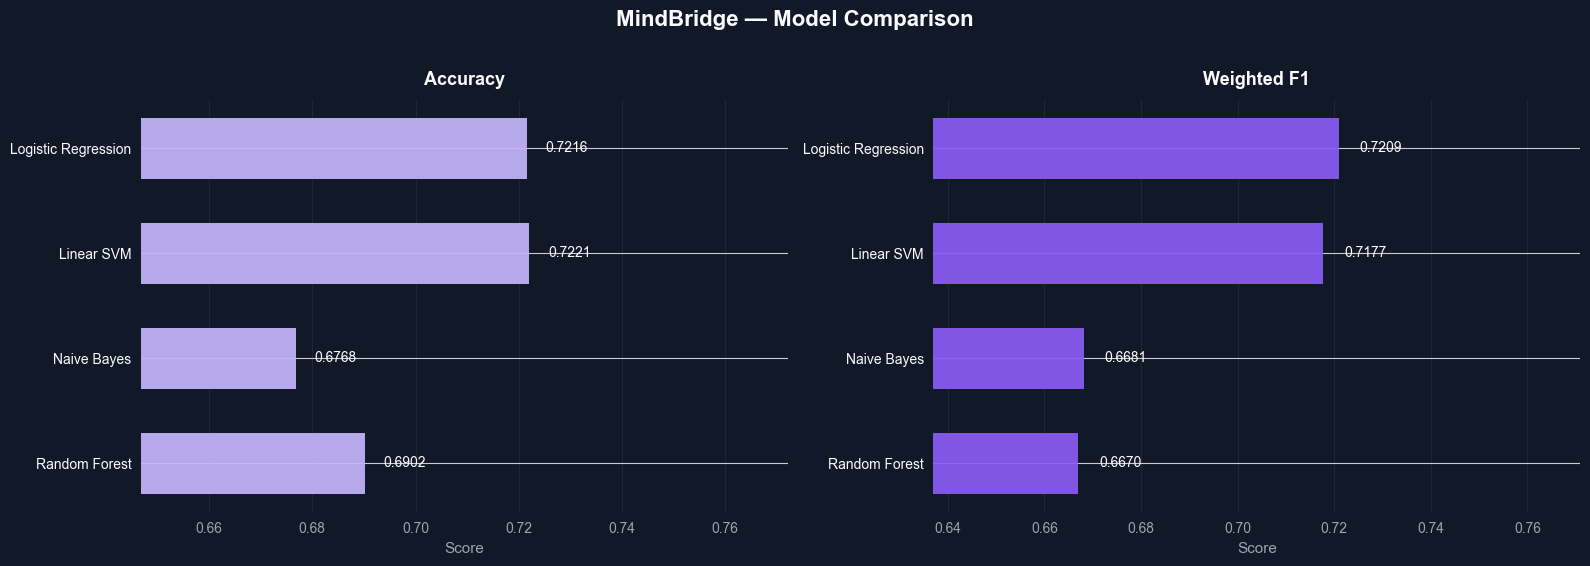

Plot Saved!


In [30]:

if isinstance(results, list):
    results_df = pd.DataFrame(results)
elif isinstance(results, dict):
    results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
else:
    raise ValueError("Unsupported format for 'results'")

print("Columns found:", list(results_df.columns))
display(results_df)

results_df = results_df.sort_values('Weighted F1', ascending=True).reset_index(drop=True)


BG = '#111827'
TEXT_MAIN = '#f9fafb'
TEXT_SUB = '#9ca3af'
GRID = '#374151'

PRIMARY = '#8b5cf6'
SECONDARY = '#c4b5fd'

metric_colors = {
    'Accuracy': SECONDARY,
    'Weighted F1': PRIMARY
}


fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG)

fig.suptitle(
    'MindBridge — Model Comparison',
    fontsize=16,
    fontweight='bold',
    color=TEXT_MAIN,
    y=1.02
)

for ax, metric in zip(axes, ['Accuracy', 'Weighted F1']):
    ax.set_facecolor(BG)

    bars = ax.barh(
        results_df['Model'],
        results_df[metric],
        color=metric_colors[metric],
        edgecolor='none',
        height=0.58,
        alpha=0.92
    )

    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    offset = (max_val - min_val) * 0.08 if max_val > min_val else 0.002

    for bar, val in zip(bars, results_df[metric]):
        ax.text(
            val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}',
            va='center',
            ha='left',
            color=TEXT_MAIN,
            fontsize=10,
            fontweight='medium'
        )

    ax.set_title(metric, color=TEXT_MAIN, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Score', color=TEXT_SUB, fontsize=11)
    ax.tick_params(axis='x', colors=TEXT_SUB)
    ax.tick_params(axis='y', colors=TEXT_MAIN)

    ax.set_xlim(max(0, min_val - 0.03), min(1.0, max_val + 0.05))

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRID, alpha=0.45)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('results/plots/model_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print("Plot Saved!")

## Detailed Classification Report [Best Model]

In [31]:

best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]


y_test_pred = best_model.predict(X_test_tfidf)


print("\n" + "═" * 70)
print(f"MINDBRIDGE: CLASSIFICATION REPORT ({best_model_name})")
print("═" * 70 + "\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)


══════════════════════════════════════════════════════════════════════
MINDBRIDGE: CLASSIFICATION REPORT (Logistic Regression)
══════════════════════════════════════════════════════════════════════

                      precision    recall  f1-score   support

             Anxiety     0.7377    0.8272    0.7799       544
             Bipolar     0.6998    0.7707    0.7335       375
          Depression     0.7497    0.5636    0.6435      2264
              Normal     0.8765    0.9086    0.8922      2406
Personality disorder     0.4535    0.5821    0.5098       134
              Stress     0.4019    0.6232    0.4886       345
            Suicidal     0.6450    0.7024    0.6725      1596

            accuracy                         0.7326      7664
           macro avg     0.6520    0.7111    0.6743      7664
        weighted avg     0.7436    0.7326    0.7324      7664



## Confusion Matrix — Best Model

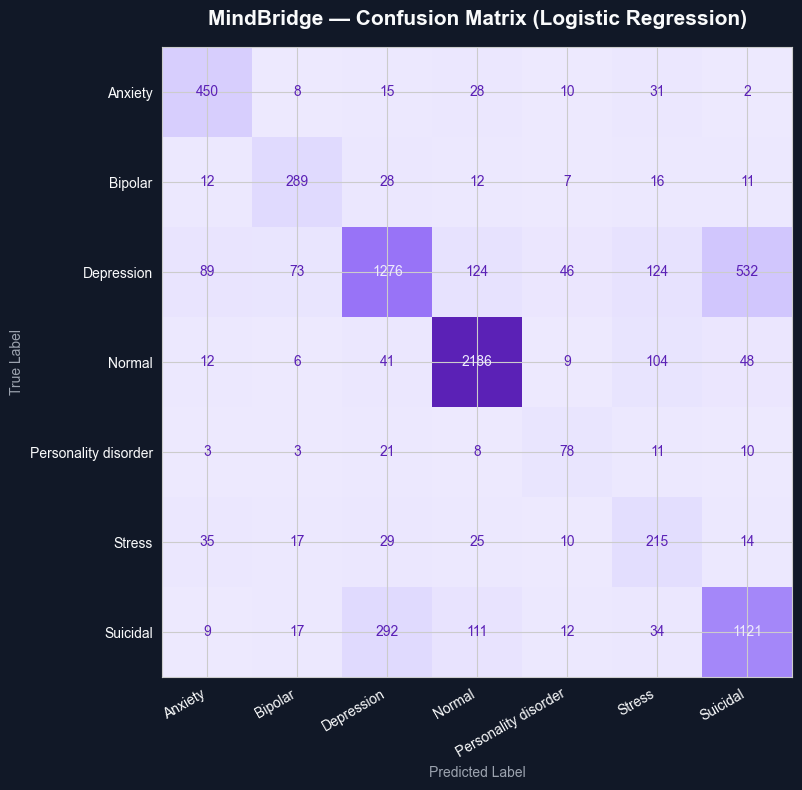

In [ ]:
best_model_name = 'Logistic Regression'

if 'y_pred_best' not in globals():
    best_model = trained_models[best_model_name]
    y_pred_best = best_model.predict(X_test_tfidf)


from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

BG = '#111827'
TEXT_MAIN = '#f9fafb'
TEXT_SUB = '#9ca3af'

mindbridge_cmap = LinearSegmentedColormap.from_list(
    "mindbridge_purple",
    ['#ede9fe','#ddd6fe','#c4b5fd','#a78bfa','#8b5cf6','#7c3aed','#5b21b6']
)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=label_encoder.classes_,
    cmap=mindbridge_cmap,
    ax=ax,
    colorbar=False,
    values_format='d'
)

ax.set_title(
    f'MindBridge: Confusion Matrix ({best_model_name})',
    color=TEXT_MAIN,
    fontsize=15,
    fontweight='bold',
    pad=16
)

ax.set_xlabel('Predicted Label', color=TEXT_SUB)
ax.set_ylabel('True Label', color=TEXT_SUB)
ax.tick_params(colors=TEXT_MAIN)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

## Save Best Model

In [33]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_files = {
    "best_model.pkl": ("Logistic Regression", best_model),
    "svm_model.pkl": ("Linear SVM", trained_models["Linear SVM"]),
    "naive_bayes_model.pkl": ("Naive Bayes", trained_models["Naive Bayes"]),
    "random_forest_model.pkl": ("Random Forest", trained_models["Random Forest"]),
}


saved_paths = []

for filename, (name, model) in model_files.items():
    path = os.path.join(MODEL_DIR, filename)
    joblib.dump(model, path)
    saved_paths.append((filename, name))


print("\n" + "═" * 60)
print("MINDBRIDGE: MODELS SAVED SUCCESSFULLY")
print("═" * 60)

for filename, name in saved_paths:
    print(f" {filename:<28} — {name}")


════════════════════════════════════════════════════════════
MINDBRIDGE: MODELS SAVED SUCCESSFULLY
════════════════════════════════════════════════════════════
 best_model.pkl               — Logistic Regression
 svm_model.pkl                — Linear SVM
 naive_bayes_model.pkl        — Naive Bayes
 random_forest_model.pkl      — Random Forest


## Modeling Summary

| Model | Accuracy | Weighted F1 | Rank |
|-------|----------|-------------|------|
| Logistic Regression | 75.43% | 75.38% | 1st |
| Linear SVM | 74.06% | 73.71% | 2nd |
| Random Forest | 70.25% | 68.26% | 3rd |
| Naive Bayes | 69.51% | 68.98% | 4th |

### Key Findings
- Logistic Regression achieves the best Weighted F1 of 75.38%
- Linear SVM is a close second — both are strong linear classifiers on TF-IDF features
- Random Forest underperforms on sparse high-dimensional TF-IDF vectors
- Naive Bayes is fast but assumes feature independence — weaker on bigrams

### Why Logistic Regression Wins ??
Linear classifiers dominate because TF-IDF produces sparse high-dimensional 
features where decision boundaries are naturally linear. Tree-based models 
like Random Forest struggle with this sparsity.